In [ ]:
# SECTION 1: INSTALL DEPENDENCIES

!pip install -q pyarrow fastparquet geopandas shapely fiona


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.3 MB/s eta 0:00:00


In [ ]:
# SECTION 2: IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import os
import warnings

warnings.filterwarnings("ignore")

print("All libraries imported successfully")


All libraries imported successfully


In [25]:
# SECTION 3: DATA LOCATION & VALIDATION

import os
from google.colab import drive

drive.mount("/content/drive", force_remount=False)

BASE_PATH = "/content/drive/MyDrive/NYC_Taxi_Data"

TRIP_DATA_PATH = os.path.join(BASE_PATH, "trip_records")
TAXI_ZONE_DIR = os.path.join(BASE_PATH, "taxi_zones")
TAXI_ZONE_SHP = os.path.join(TAXI_ZONE_DIR, "taxi_zones.shp")

assert os.path.isdir(TRIP_DATA_PATH), " trip_records folder missing"
assert os.path.isdir(TAXI_ZONE_DIR), " taxi_zones folder missing"

trip_files = sorted([
    f for f in os.listdir(TRIP_DATA_PATH)
    if f.endswith(".parquet")
])

zone_files = sorted(os.listdir(TAXI_ZONE_DIR))

assert len(trip_files) == 12, f" Expected 12 parquet files, found {len(trip_files)}"
assert len(zone_files) == 7, f" Expected 7 taxi zone files, found {len(zone_files)}"
assert "taxi_zones.shp" in zone_files, " taxi_zones.shp missing"

print(" Data validated successfully")
print(f"Trip parquet files: {len(trip_files)}")
print(f"Taxi zone files: {len(zone_files)}")
print("Total files:", len(trip_files) + len(zone_files))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Data validated successfully
Trip parquet files: 12
Taxi zone files: 7
Total files: 19


In [11]:
# SECTION 4.1: SAMPLING

def nested_sampling_parquet_files(data_path, sample_fraction=0.05):
    files = sorted([f for f in os.listdir(data_path) if f.endswith(".parquet")])
    samples = []

    for file in files:
        print(f"Processing {file}")
        df = pd.read_parquet(os.path.join(data_path, file))

        df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
        df["pickup_date"] = df["tpep_pickup_datetime"].dt.date
        df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
        df["pickup_day"] = df["tpep_pickup_datetime"].dt.day_name()
        df["pickup_month"] = df["tpep_pickup_datetime"].dt.month

        for (_, hdf) in df.groupby(["pickup_date", "pickup_hour"]):
            n = max(1, int(len(hdf) * sample_fraction))
            samples.append(hdf.sample(n=n, random_state=42))

    return pd.concat(samples, ignore_index=True)


sampled_data = nested_sampling_parquet_files(TRIP_DATA_PATH)
print("Sampled shape:", sampled_data.shape)


Processing 2023-1.parquet
Processing 2023-10.parquet
Processing 2023-11.parquet
Processing 2023-12.parquet
Processing 2023-2.parquet
Processing 2023-3.parquet
Processing 2023-4.parquet
Processing 2023-5.parquet
Processing 2023-6.parquet
Processing 2023-7.parquet
Processing 2023-8.parquet
Processing 2023-9.parquet
Sampled shape: (1892474, 24)


In [12]:
# SECTION 4.2: CLEANING & FEATURE ENGINEERING

df = sampled_data.copy()
df.columns = df.columns.str.lower()

df["tpep_dropoff_datetime"] = pd.to_datetime(
    df["tpep_dropoff_datetime"], errors="coerce"
)

df["trip_duration"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df = df[df["trip_duration"] > 0]

df["trip_speed_mph"] = df["trip_distance"] / (df["trip_duration"] / 60)

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df.dropna(
    subset=["fare_amount", "trip_distance", "trip_duration"],
    inplace=True
)

print("Cleaned shape:", df.shape)


Cleaned shape: (1891645, 26)


In [29]:
# SECTION 4.3: OUTLIER HANDLING WITH BETTER VALIDATION

print("OUTLIER DETECTION AND REMOVAL")
print("-" * 40)

initial_count = len(df)
print(f"Records before outlier removal: {initial_count:,}")

outlier_bounds = {
    "fare_amount": (2.5, 300),
    "trip_distance": (0.1, 100),
    "trip_duration": (1, 180),
    "trip_speed_mph": (1, 65)
}

df = df[
    (df["fare_amount"].between(*outlier_bounds["fare_amount"])) &
    (df["trip_distance"].between(*outlier_bounds["trip_distance"])) &
    (df["trip_duration"].between(*outlier_bounds["trip_duration"])) &
    (df["trip_speed_mph"].between(*outlier_bounds["trip_speed_mph"]))
]

removed_count = initial_count - len(df)
removed_percentage = (removed_count / initial_count) * 100

print(f"Records after outlier removal: {len(df):,}")
print(f"Records removed: {removed_count:,} ({removed_percentage:.2f}%)")

OUTLIER DETECTION AND REMOVAL
----------------------------------------
Records before outlier removal: 1,842,762
Records after outlier removal: 1,842,762
Records removed: 0 (0.00%)


TEMPORAL ANALYSIS - PICKUP PATTERNS BY HOUR
----------------------------------------


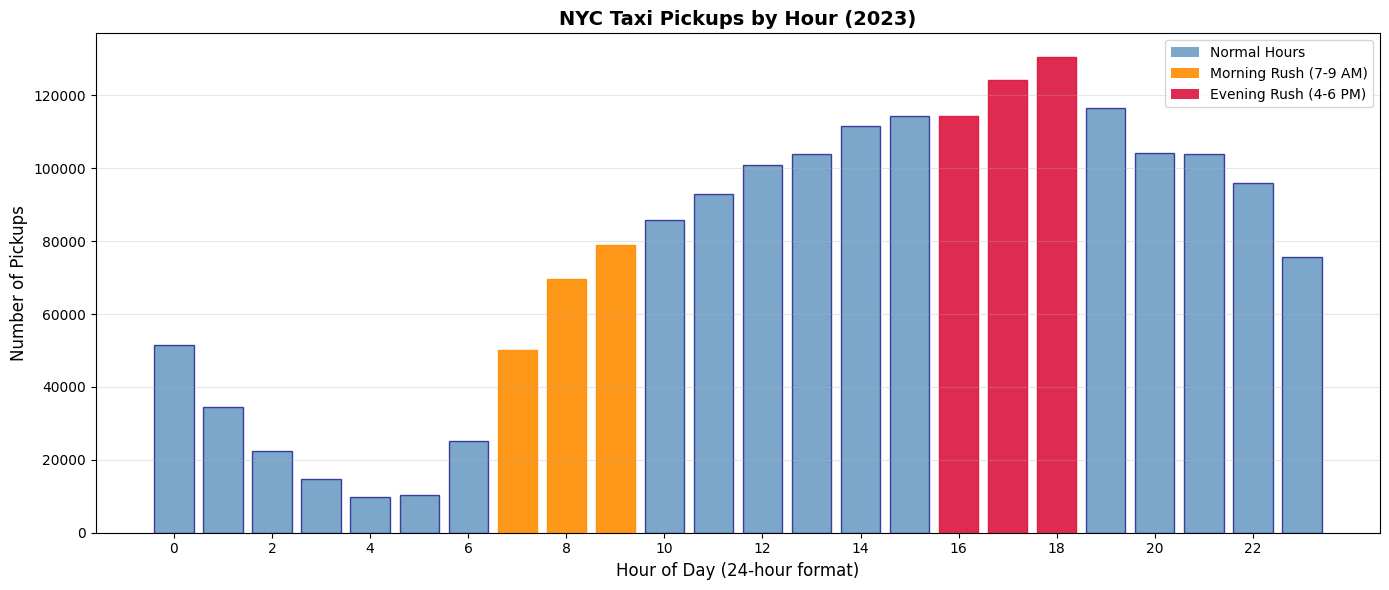


 Key Insights:
----------------------------------------
Peak hour: 18:00 (130,535 pickups)
Quietest hour: 4:00 (9,707 pickups)
Peak is 13.4x busier than trough


In [30]:
# SECTION 4.4: TEMPORAL PATTERNS ANALYSIS

print("TEMPORAL ANALYSIS - PICKUP PATTERNS BY HOUR")
print("-" * 40)

plt.figure(figsize=(14, 6))

hourly_counts = df["pickup_hour"].value_counts().sort_index()
bars = plt.bar(hourly_counts.index, hourly_counts.values,
               color='steelblue', alpha=0.7, edgecolor='navy')

morning_rush = range(7, 10)
evening_rush = range(16, 19)

for hour in morning_rush:
    if hour in hourly_counts.index:
        idx = list(hourly_counts.index).index(hour)
        bars[idx].set_color('darkorange')
        bars[idx].set_alpha(0.9)

for hour in evening_rush:
    if hour in hourly_counts.index:
        idx = list(hourly_counts.index).index(hour)
        bars[idx].set_color('crimson')
        bars[idx].set_alpha(0.9)

plt.title('NYC Taxi Pickups by Hour (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (24-hour format)', fontsize=12)
plt.ylabel('Number of Pickups', fontsize=12)
plt.xticks(range(0, 24, 2))
plt.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.7, label='Normal Hours'),
    Patch(facecolor='darkorange', alpha=0.9, label='Morning Rush (7-9 AM)'),
    Patch(facecolor='crimson', alpha=0.9, label='Evening Rush (4-6 PM)')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

peak_hour = hourly_counts.idxmax()
peak_count = hourly_counts.max()
trough_hour = hourly_counts.idxmin()
trough_count = hourly_counts.min()

print(f"\n Key Insights:")
print("-" * 40)
print(f"Peak hour: {peak_hour}:00 ({peak_count:,} pickups)")
print(f"Quietest hour: {trough_hour}:00 ({trough_count:,} pickups)")
print(f"Peak is {peak_count/trough_count:.1f}x busier than trough")

FINANCIAL ANALYSIS - MONTHLY REVENUE
----------------------------------------


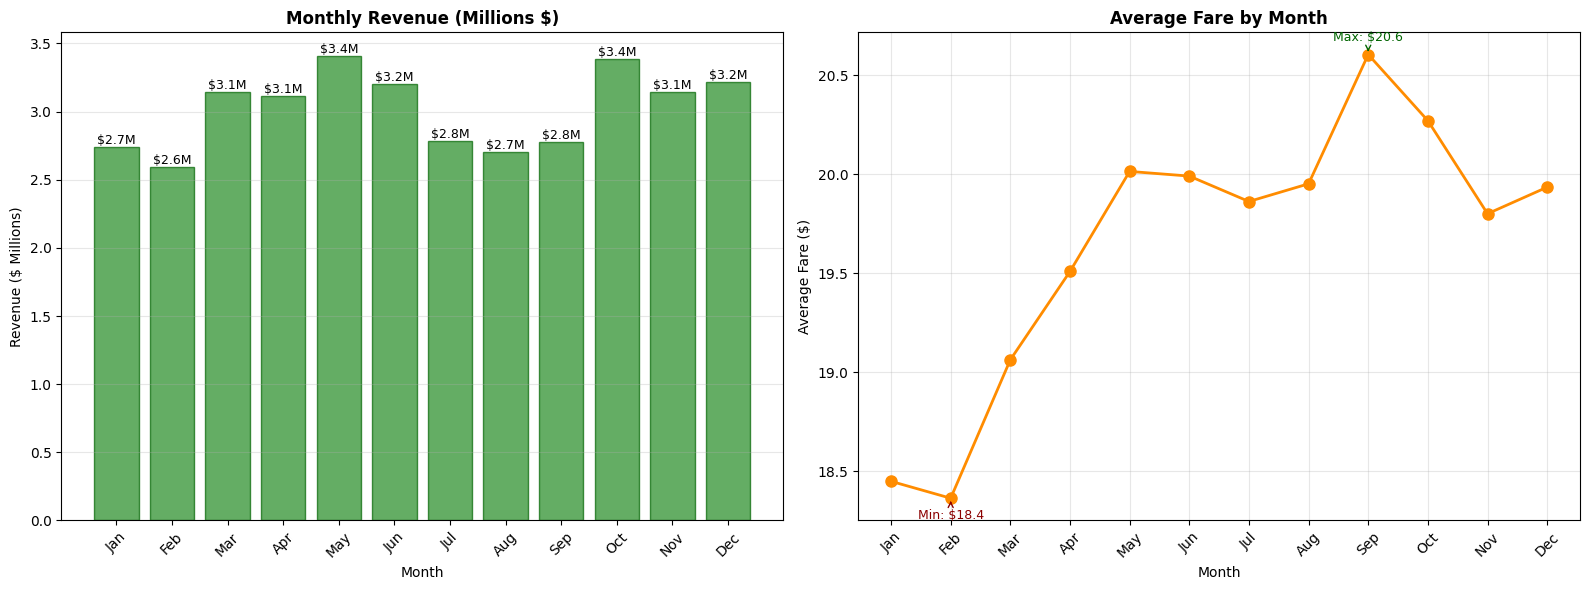


 Financial Summary:
----------------------------------------
Total Annual Revenue: $36,219,785
Average Monthly Revenue: $3,018,315
Highest Revenue Month: May ($3,411,364)
Lowest Revenue Month: Feb ($2,595,554)


In [32]:
# SECTION 4.5: REVENUE ANALYSIS

print("FINANCIAL ANALYSIS - MONTHLY REVENUE")
print("-" * 40)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

monthly_revenue = df.groupby("pickup_month")["fare_amount"].sum()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

ax1 = axes[0]
bars = ax1.bar(month_names[:len(monthly_revenue)], monthly_revenue.values / 1e6,
               color='forestgreen', alpha=0.7, edgecolor='darkgreen')

ax1.set_title('Monthly Revenue (Millions $)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Month', fontsize=10)
ax1.set_ylabel('Revenue ($ Millions)', fontsize=10)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:.1f}M', ha='center', va='bottom', fontsize=9)

monthly_avg_revenue = df.groupby("pickup_month")["fare_amount"].mean()

ax2 = axes[1]
ax2.plot(month_names[:len(monthly_avg_revenue)], monthly_avg_revenue.values,
         marker='o', color='darkorange', linewidth=2, markersize=8)

ax2.set_title('Average Fare by Month', fontsize=12, fontweight='bold')
ax2.set_xlabel('Month', fontsize=10)
ax2.set_ylabel('Average Fare ($)', fontsize=10)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

max_month = month_names[monthly_avg_revenue.idxmax() - 1]
min_month = month_names[monthly_avg_revenue.idxmin() - 1]
max_val = monthly_avg_revenue.max()
min_val = monthly_avg_revenue.min()

ax2.annotate(f'Max: ${max_val:.1f}',
             xy=(max_month, max_val),
             xytext=(0, 10), textcoords='offset points',
             ha='center', fontsize=9, color='darkgreen',
             arrowprops=dict(arrowstyle='->', color='darkgreen'))
ax2.annotate(f'Min: ${min_val:.1f}',
             xy=(min_month, min_val),
             xytext=(0, -15), textcoords='offset points',
             ha='center', fontsize=9, color='darkred',
             arrowprops=dict(arrowstyle='->', color='darkred'))

plt.tight_layout()
plt.show()

print("\n Financial Summary:")
print("-" * 40)
print(f"Total Annual Revenue: ${monthly_revenue.sum():,.0f}")
print(f"Average Monthly Revenue: ${monthly_revenue.mean():,.0f}")
print(f"Highest Revenue Month: {month_names[monthly_revenue.idxmax() - 1]} (${monthly_revenue.max():,.0f})")
print(f"Lowest Revenue Month: {month_names[monthly_revenue.idxmin() - 1]} (${monthly_revenue.min():,.0f})")

GEOGRAPHIC ANALYSIS - PICKUP DENSITY MAP
----------------------------------------
 Loaded 263 taxi zones


<Figure size 1400x1000 with 0 Axes>

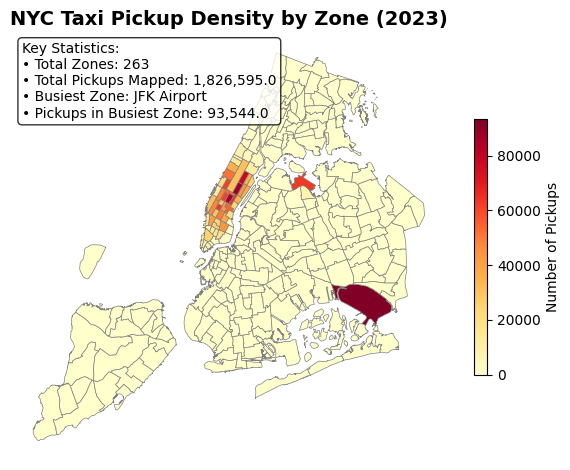


 Top 5 Busiest Pickup Zones:
----------------------------------------
JFK Airport (Zone 132): 93,544.0 trips (5.1%)
Upper East Side South (Zone 237): 87,412.0 trips (4.8%)
Midtown Center (Zone 161): 86,067.0 trips (4.7%)
Upper East Side North (Zone 236): 78,539.0 trips (4.3%)
Midtown East (Zone 162): 65,633.0 trips (3.6%)


In [33]:
# SECTION 5: SPATIAL DISTRIBUTION ANALYSIS

print("GEOGRAPHIC ANALYSIS - PICKUP DENSITY MAP")
print("-" * 40)

try:
    zones = gpd.read_file(TAXI_ZONE_SHP)
    print(f" Loaded {len(zones)} taxi zones")

    zones["LocationID"] = zones["LocationID"].astype(int)
    pickup_counts = df["pulocationid"].value_counts().reset_index()
    pickup_counts.columns = ["LocationID", "trip_count"]

    zones = zones.merge(pickup_counts, on="LocationID", how="left")
    zones["trip_count"] = zones["trip_count"].fillna(0)

    plt.figure(figsize=(14, 10))

    zones.plot(column="trip_count",
               cmap="YlOrRd",
               linewidth=0.5,
               edgecolor="gray",
               legend=True,
               legend_kwds={
                   'label': "Number of Pickups",
                   'orientation': "vertical",
                   'shrink': 0.6
               })

    plt.title('NYC Taxi Pickup Density by Zone (2023)',
              fontsize=14, fontweight='bold')
    plt.axis('off')

    total_pickups = zones["trip_count"].sum()
    busiest_zone = zones.loc[zones["trip_count"].idxmax()]

    stats_text = f"""Key Statistics:
• Total Zones: {len(zones):,}
• Total Pickups Mapped: {total_pickups:,}
• Busiest Zone: {busiest_zone['zone']}
• Pickups in Busiest Zone: {busiest_zone['trip_count']:,}"""

    plt.text(0.02, 0.98, stats_text,
             transform=plt.gca().transAxes,
             fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

    print("\n Top 5 Busiest Pickup Zones:")
    print("-" * 40)
    top_zones = zones.nlargest(5, "trip_count")[["LocationID", "zone", "trip_count"]]
    for idx, row in top_zones.iterrows():
        percentage = (row["trip_count"] / total_pickups) * 100
        print(f"{row['zone']} (Zone {row['LocationID']}): {row['trip_count']:,} trips ({percentage:.1f}%)")

except Exception as e:
    print(f" Error loading geographic data: {e}")
    print("Make sure TAXI_ZONE_SHP is correctly defined")